# Diagnóstico y Corrección de las Hipótesis del Modelo Lineal Múltiple

In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.stats.api as sms
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import acorr_ljungbox

# Cargar datos:
from google.colab import drive
drive.mount('/content/drive')

data = pd.read_csv("/content/drive/MyDrive/archive/datos_limpios.csv")

data.info()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Columns: 204 entries, hours_studied to student_id_S200
dtypes: bool(199), float64(5)
memory usage: 46.8 KB


- year      - 1959q1 - 2009q3
- quarter   - 1-4
- realgdp   - Real gross domestic product (Bil. of chained 2005 US$,
            seasonally adjusted annual rate)
- realcons  - Real personal consumption expenditures (Bil. of chained
            2005 US$, seasonally adjusted annual rate)
- realinv   - Real gross private domestic investment (Bil. of chained
            2005 US$, seasonally adjusted annual rate)
- realgovt  - Real federal consumption expenditures & gross investment
            (Bil. of chained 2005 US$, seasonally adjusted annual rate)
- realdpi   - Real private disposable income (Bil. of chained 2005
            US$, seasonally adjusted annual rate)
- cpi       - End of the quarter consumer price index for all urban
            consumers: all items (1982-84 = 100, seasonally adjusted).
- m1        - End of the quarter M1 nominal money stock (Seasonally
            adjusted)
- tbilrate  - Quarterly monthly average of the monthly 3-month
            treasury bill: secondary market rate
- unemp     - Seasonally adjusted unemployment rate (%)
- pop       - End of the quarter total population: all ages incl. armed
            forces over seas
- infl      - Inflation rate (ln(cpi_{t}/cpi_{t-1}) * 400)
- realint   - Real interest rate (tbilrate - infl)

In [72]:
y = data['exam_score']
X = data[['hours_studied', 'sleep_hours', 'attendance_percent', 'previous_scores']]
X = sm.add_constant(X)

modelo = sm.OLS(y, X).fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:             exam_score   R-squared:                       0.841
Model:                            OLS   Adj. R-squared:                  0.838
Method:                 Least Squares   F-statistic:                     258.7
Date:                Mon, 01 Dec 2025   Prob (F-statistic):           8.76e-77
Time:                        09:10:45   Log-Likelihood:                -482.21
No. Observations:                 200   AIC:                             974.4
Df Residuals:                     195   BIC:                             990.9
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -2.1421      1

## Normalidad

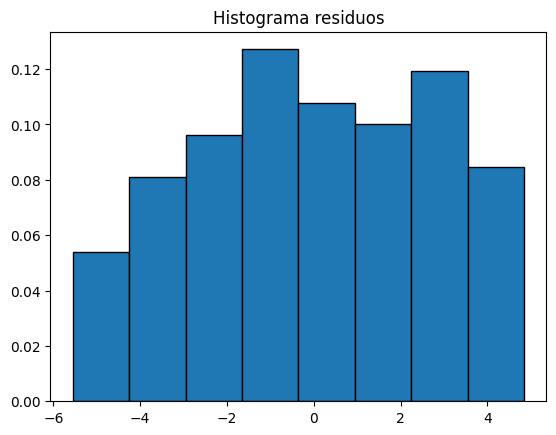

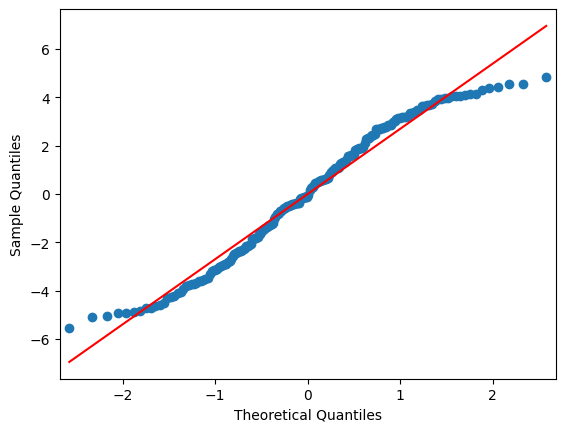

KstestResult(statistic=np.float64(0.06853004451154299), pvalue=np.float64(0.2911105064275469), statistic_location=np.float64(0.9884344738262884), statistic_sign=np.int8(-1))

In [73]:
resid = modelo.resid
resid_std = (resid - resid.mean())/resid.std(ddof=1)

plt.hist(resid, bins=8, edgecolor='black', density=True)
plt.title('Histograma residuos')
plt.show()

sm.qqplot(resid, line='s')
plt.show()

stats.kstest(resid_std, 'norm')

## Multicolinealidad

In [74]:
vif = pd.DataFrame()
vif['var']=X.columns
vif['VIF']=[variance_inflation_factor(X.values,i) for i in range(X.shape[1])]
vif

,var,VIF
0,const,74.840675
1,hours_studied,1.014944
2,sleep_hours,1.048547
3,attendance_percent,1.004142
4,previous_scores,1.050271


In [48]:
cond=np.linalg.cond(X.values.T@X.values)
np.sqrt(cond)

np.float64(882.2724502346254)

## Heteroscedasticidad

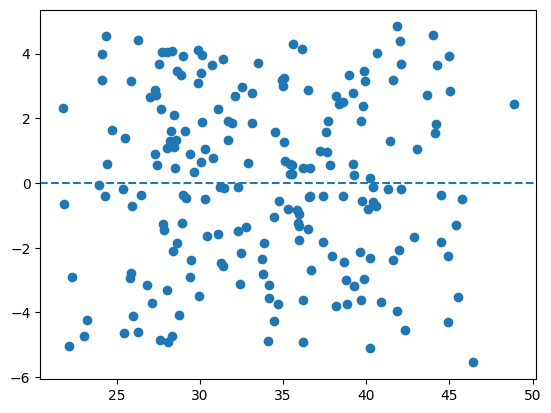

In [75]:
fitted = modelo.fittedvalues
plt.scatter(fitted, resid); plt.axhline(0,ls='--'); plt.show()

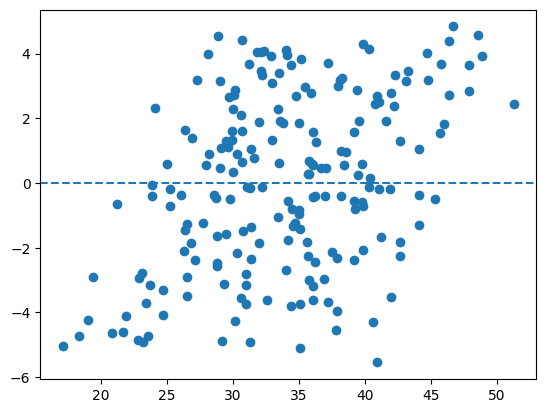

In [65]:
plt.scatter(data['exam_score'], resid); plt.axhline(0,ls='--'); plt.show()

LOS GRAFICOS ESTAN PERFECTOS JUUJUUU

In [76]:
sms.het_goldfeldquandt(y,X)

(np.float64(1.009456511324037), np.float64(0.48175548664435264), 'increasing')

p valor grande nos confirma q esta bien homocedasticidad

In [77]:
sms.het_breuschpagan(resid,X)

(np.float64(0.9069046911912793),
 np.float64(0.923568145970984),
 np.float64(0.22206497732630529),
 np.float64(0.9258806269412347))

p valor grande nos confirma q esta bien homocedasticidad

In [78]:
sms.het_white(resid,X)

(np.float64(18.0284755863267),
 np.float64(0.205486990666018),
 np.float64(1.3091797090690567),
 np.float64(0.20520016986831482))

p valor grande nos confirma q esta bien homocedasticidad

In [79]:
glejser_y = np.abs(resid)

for v in ['hours_studied', 'sleep_hours']:
    print(f"Variable {v}:")
    for h in [-3, -2, -1, 1, 2, 3]:
        z = X[v]**h
        Z = pd.DataFrame({'zvar': z})

        glejser = sm.OLS(glejser_y, sm.add_constant(Z)).fit()

        pval = glejser.pvalues['zvar']
        print(f"\t p-valor {v}^{h}: {pval}. R^2: {glejser.rsquared}")

Variable hours_studied:
	 p-valor hours_studied^-3: 0.9938714093999841. R^2: 2.987315437241733e-07
	 p-valor hours_studied^-2: 0.8104185883121672. R^2: 0.0002913253214670286
	 p-valor hours_studied^-1: 0.5478120765990293. R^2: 0.0018274424845297066
	 p-valor hours_studied^1: 0.4093901102726507. R^2: 0.0034399861132096143
	 p-valor hours_studied^2: 0.5629420251295348. R^2: 0.001692917862714638
	 p-valor hours_studied^3: 0.7643492061479221. R^2: 0.00045490623926680573
Variable sleep_hours:
	 p-valor sleep_hours^-3: 0.6340182048349323. R^2: 0.0011469381648127053
	 p-valor sleep_hours^-2: 0.638418005677921. R^2: 0.0011174328093224162
	 p-valor sleep_hours^-1: 0.6457808546909671. R^2: 0.0010691002603020472
	 p-valor sleep_hours^1: 0.6642849984040105. R^2: 0.0009532642081402365
	 p-valor sleep_hours^2: 0.6724711219548156. R^2: 0.0009045250733200616
	 p-valor sleep_hours^3: 0.6784725472065151. R^2: 0.000869746982420927


ESTAN BIEN PORQUE EL P VALOR ES BASTANTE GRANDE

### Mínimos Cuadrados Ponderados

ESTO CREO Q NO TENEMOS QUE HACELRO PORQUE NO TENEMOS PROBLEMAS DE HETEROCEDASTICIDAD





In [70]:
weights = 1/data['hours_studied']
wls_results = sm.WLS(y,X,weights=weights).fit()
wls_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            WLS Regression Results                            
==============================================================================
Dep. Variable:             exam_score   R-squared:                       0.818
Model:                            WLS   Adj. R-squared:                  0.814
Method:                 Least Squares   F-statistic:                     219.0
Date:                Mon, 01 Dec 2025   Prob (F-statistic):           6.13e-71
Time:                        09:10:35   Log-Likelihood:                -507.12
No. Observations:                 200   AIC:                             1024.
Df Residuals:                     195   BIC:                             1041.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
======================================================================================
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -3.4632      1.710     -2.026      0.044      -6.835      -0.092
hours_studied          1.5664      0.066     23.610      0.000       1.436       1.697
sleep_hours            0.9715      0.131      7.399      0.000       0.713       1.230
attendance_percent     0.1166      0.014      8.361      0.000       0.089       0.144
previous_scores        0.1848      0.013     14.020      0.000       0.159       0.211
==============================================================================
Omnibus:                        1.315   Durbin-Watson:                   2.074
Prob(Omnibus):                  0.518   Jarque-Bera (JB):                1.140
Skew:                          -0.184   Prob(JB):                        0.566
Kurtosis:                       3.039   Cond. No.                         890.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Autocorrelación

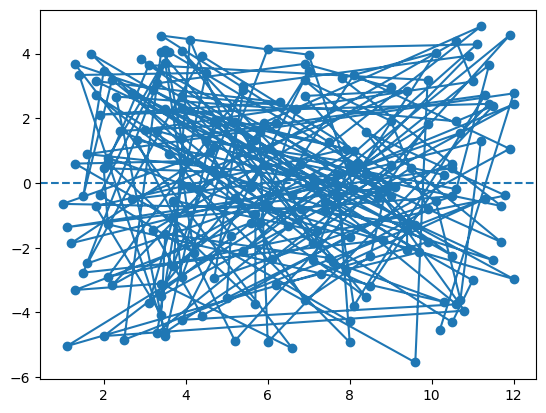

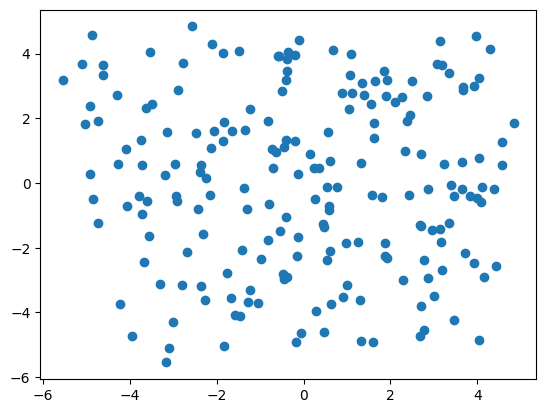

np.float64(2.0342820108897213)

In [80]:
plt.plot(data['hours_studied'], modelo.resid, marker='o'); plt.axhline(0,ls='--'); plt.show()

plt.scatter(modelo.resid[:-1], modelo.resid[1:]); plt.show()

durbin_watson(modelo.resid)

ESTA BIEN PORQUE NO HAY NINGUNA TENDENCIA ENTRE LOS RESIDUOS

In [83]:
acorr_ljungbox(modelo.resid,lags=[1,2,3,4,5],return_df=True)

,lb_stat,lb_pvalue
1,0.188597,0.664087
2,2.097816,0.350320
3,4.321230,0.228801
4,4.341105,0.361806
5,4.909816,0.426985


no se rechaza por ser grandes (hay q mirarlo bien)

## Prais-Winsten

In [82]:
dw = durbin_watson(modelo.resid)
rho = 1 - (dw/2)

mco_autocorr=sm.GLSAR(y, sm.add_constant(X), rho=rho)
res=mco_autocorr.iterative_fit(maxiter=100,rtol=10**(-10))


print ('Iteraciones = %d Converge: %s' % (res.iter, res.converged) )
print ('Rho =  ', mco_autocorr.rho)
print(res.summary())

Iteraciones = 9 Converge: True
Rho =   [-0.03601301]
                           GLSAR Regression Results                           
Dep. Variable:             exam_score   R-squared:                       0.842
Model:                          GLSAR   Adj. R-squared:                  0.839
Method:                 Least Squares   F-statistic:                     259.4
Date:                Mon, 01 Dec 2025   Prob (F-statistic):           1.16e-76
Time:                        09:11:07   Log-Likelihood:                -478.89
No. Observations:                 199   AIC:                             967.8
Df Residuals:                     194   BIC:                             984.2
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------

Rho =   [-0.03601301] NOS FIJAMOS Q ES MUY PROXIMO A 0 (BUENO)